## <span style="color:#4375c7">Data and AI in Economics</span>
***
*The course material is for educational purposes only. Nothing herein should be taken as an investment advice or offers any opinion regarding the suitability of any security. For more information about this course, please contact us.*
***
## 6. Hands-on session — Transformers & GPT <a id='ho'></a>

This exercise notebook accompanies lecture 06. Work through the four exercises to build a character-level GPT from scratch.

In [3]:
#!pip install -q -r https://raw.githubusercontent.com/firrm/DAI/main/requirements_colab.txt

import numpy as np
import matplotlib.pyplot as plt
import math
import urllib.request

## 2. Hands-on session <a id='ho'></a>

### Exercise 1 — Character-level tokenizer

Build a character-level tokenizer for a list of first names.

A tokenizer maps every unique character to a unique integer id and provides:
- `encode(name)` → list of ints (wrap in BOS tokens)
- `decode(ids)` → string (skip BOS tokens)

**Tasks:**
1. Extract all unique characters from `names` and sort them.
2. Build `stoi` (char → id) and `itos` (id → char) dictionaries. Assign id 0 to the special `BOS` token and ids 1–26 to the 26 lowercase letters.
3. Implement `encode(name)` and `decode(ids)`.
4. Verify the round-trip: `decode(encode(name)) == name` for several names.
5. Print the number of unique tokens and the vocabulary.

In [6]:
# Fetch the names dataset
url = "https://raw.githubusercontent.com/karpathy/micrograd/master/names.txt"
try:
    with urllib.request.urlopen(url) as r:
        names_text = r.read().decode()
except Exception:
    names_text = "emma\nolivia\nava\nisabella\nsophia\ncharlotte\nmia\namelia\nharper\nevelyn\n"

names = [n.strip() for n in names_text.strip().split("\n") if n.strip()]
print(f"Loaded {len(names):,} names. First 5: {names[:5]}")

Loaded 10 names. First 5: ['emma', 'olivia', 'ava', 'isabella', 'sophia']


In [20]:
# 1. Extract and sort unique characters
chars = sorted(set("".join(names)))
print (chars)
# 2. Build the vocabulary by prepending the special BOS token
vocab = ["BOS"] + chars
vocab_size = len(vocab)

# 3. Create the lookup tables (String-to-Integer and Integer-to-String)
stoi = {s: i for i, s in enumerate(vocab)}
itos = {i: s for s, i in stoi.items()}

# 4. Extract the BOS integer ID for easy reference
BOS = stoi["BOS"]
e=stoi["e"]

print(f"Vocabulary ({vocab_size} tokens):", vocab)
print(f"BOS token ID: {BOS}")
print(f"BOS token ID: {e}")

['a', 'b', 'c', 'e', 'h', 'i', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'v', 'y']
Vocabulary (17 tokens): ['BOS', 'a', 'b', 'c', 'e', 'h', 'i', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'v', 'y']
BOS token ID: 0
BOS token ID: 4


In [29]:
def encode(name):
    """Encode a name as a list of integer ids, wrapped in BOS tokens."""
    # Start with BOS, add IDs for each character, end with BOS
    ids = [BOS] + [stoi[c] for c in name] + [BOS]
    return ids

def decode(ids):
    """Decode a list of integer ids back to a string (ignore BOS tokens)."""
    # Join the characters only if the ID is not the BOS token
    return "".join([itos[i] for i in ids if i != BOS])

# Verify round-trip
for test_name in ["emma", "olivia", "ava"]:
    assert decode(encode(test_name)) == test_name, f"Round-trip failed for '{test_name}'"
    print(f"encode('{test_name}') = {encode(test_name)}")
    

print(encode("leil"))
print(decode(encode("leil")))

encode('emma') = [0, 4, 8, 8, 1, 0]
encode('olivia') = [0, 10, 7, 6, 15, 6, 1, 0]
encode('ava') = [0, 1, 15, 1, 0]
[0, 7, 4, 6, 7, 0]
leil


### Exercise 2 — Softmax & cross-entropy loss

Implement the two core building blocks used to turn model outputs into a training signal.

**Tasks:**
1. Implement `softmax(logits)` with numerical stability (subtract max before exponentiation).
2. Implement `cross_entropy_loss(probs, target_id)` using $-\log(p_{\text{target}})$.
3. Verify: `softmax` output is non-negative and sums to 1.
4. Plot the loss $-\log(p)$ as a function of $p \in (0, 1)$ and mark the random-baseline loss $-\log(1/27)$.

In [30]:
import numpy as np

def softmax(logits):
    """Numerically stable softmax. Input: 1-D array. Output: probability array."""
    logits = np.array(logits, dtype=float)
    # Subtracting the max doesn't change the output distribution, 
    # but it prevents exp() from exploding.
    exps = np.exp(logits - np.max(logits))
    return exps / np.sum(exps)

def cross_entropy_loss(probs, target_id):
    """Cross-entropy loss for a single prediction."""
    # Loss = -log(probability of the correct class)
    # We add a tiny epsilon to avoid log(0) if probs[target_id] is exactly 0
    return -np.log(probs[target_id] + 1e-15)

# Verify
logits_test = np.array([2.0, 1.0, 0.1, -1.0, 3.0])
probs_test  = softmax(logits_test)
assert abs(probs_test.sum() - 1.0) < 1e-9, "Probs must sum to 1"
assert (probs_test >= 0).all(), "Probs must be non-negative"
print("softmax probs:", np.round(probs_test, 4), "  sum:", probs_test.sum().round(6))

loss_high_conf = cross_entropy_loss(np.array([0.01, 0.99]), 1)
loss_low_conf  = cross_entropy_loss(np.array([0.99, 0.01]), 1)
print(f"Loss when model is 99% confident and correct:   {loss_high_conf:.4f}")
print(f"Loss when model is  1% confident and correct:   {loss_low_conf:.4f}")

softmax probs: [0.2333 0.0858 0.0349 0.0116 0.6343]   sum: 1.0
Loss when model is 99% confident and correct:   0.0101
Loss when model is  1% confident and correct:   4.6052


<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Leila\AppData\Local\Temp\ipykernel_17092\2898129817.py:10: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(p_vals, loss_vals, label='Cross-Entropy Loss: $-\log(p)$', color='blue', linewidth=2)


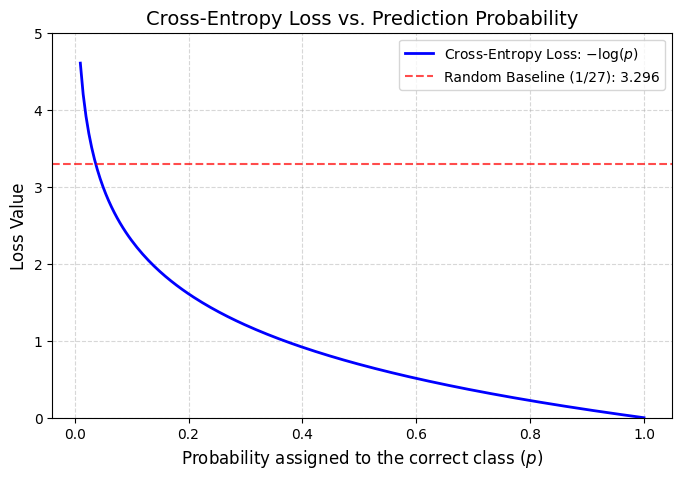

In [10]:
import matplotlib.pyplot as plt

# 1. Calculate values
p_vals = np.linspace(0.01, 1.0, 200)
loss_vals = -np.log(p_vals)
random_baseline = -np.log(1/27)

# 2. Create the plot
plt.figure(figsize=(8, 5))
plt.plot(p_vals, loss_vals, label='Cross-Entropy Loss: $-\log(p)$', color='blue', linewidth=2)

# 3. Add the random baseline line
plt.axhline(y=random_baseline, color='red', linestyle='--', alpha=0.7, 
            label=f'Random Baseline (1/27): {random_baseline:.3f}')

# 4. Formatting
plt.title('Cross-Entropy Loss vs. Prediction Probability', fontsize=14)
plt.xlabel('Probability assigned to the correct class ($p$)', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.ylim(0, 5) # Keeping the focus on the relevant range

plt.show()

### Exercise 3 — Scaled dot-product attention

Implement the core of the Transformer: scaled dot-product attention with a causal mask.

Given queries $Q$, keys $K$, values $V$ (all shape `(T, d_k)`):

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + M\right) V$$

where $M$ is a causal mask with $-\infty$ in the upper triangle (future positions).

**Tasks:**
1. Implement `attention(Q, K, V)` — compute scaled scores, apply causal mask, softmax, weight `V`.
2. Create random `Q`, `K`, `V` matrices (shape `(6, 4)`) and call your function.
3. Visualise the attention weight matrix as a heatmap. Verify the upper triangle is zero.

In [31]:
def attention(Q, K, V):
    """
    Scaled dot-product attention with causal masking.
    Q, K, V: arrays of shape (T, d_k)
    Returns: output of shape (T, d_k)
    """
    T, dk = Q.shape
    
    # 1. Compute scaled scores: (T, dk) @ (dk, T) -> (T, T)
    # We divide by the square root of dk to keep gradients stable
    scores = (Q @ K.T) / np.sqrt(dk)

    # 2. Apply causal mask (upper triangle → -inf)
    # np.tril returns the lower triangle; we mask everything where tril is 0
    mask = np.tril(np.ones((T, T)))
    scores = np.where(mask == 0, -np.inf, scores)

    # 3. Softmax applied row-wise
    # Each row represents the attention weights for a specific time step
    weights = np.apply_along_axis(softmax, 1, scores)

    # 4. Weighted sum of values: (T, T) @ (T, d_k) -> (T, d_k)
    return weights @ V

# Test
np.random.seed(7)
T, dk = 6, 4
Q_test = np.random.randn(T, dk)
K_test = np.random.randn(T, dk)
V_test = np.random.randn(T, dk)
out_test = attention(Q_test, K_test, V_test)

print("Attention output shape:", out_test.shape) # expected: (6, 4)
print("\nTop-left of attention weights (causal check):")
# Re-calculating weights for display to show the masking effect
temp_scores = (Q_test @ K_test.T) / np.sqrt(dk)
temp_weights = np.apply_along_axis(softmax, 1, np.where(np.tril(np.ones((T, T))) == 0, -np.inf, temp_scores))
print(np.round(temp_weights[:3, :3], 2))

Attention output shape: (6, 4)

Top-left of attention weights (causal check):
[[1.   0.   0.  ]
 [0.97 0.03 0.  ]
 [0.24 0.48 0.28]]


✓ Causal mask verified: no future tokens are attended to


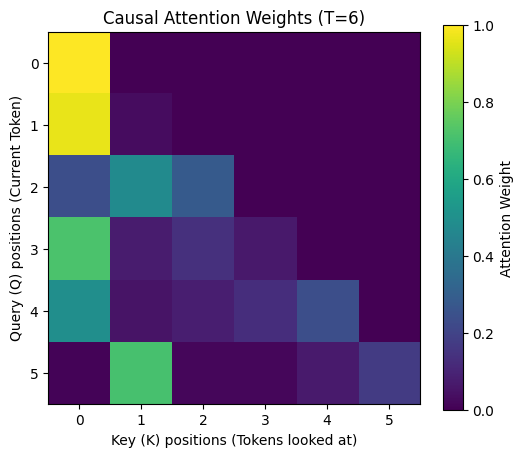

In [13]:
import matplotlib.pyplot as plt

# 1. Recompute the weight matrix
scores_viz = (Q_test @ K_test.T) / np.sqrt(dk)
mask_viz = np.tril(np.ones((T, T)))
# Apply mask: where mask is 0, replace with -inf
masked_scores = np.where(mask_viz == 0, -np.inf, scores_viz)
weights_viz = np.apply_along_axis(softmax, 1, masked_scores)

# 2. Plot as heatmap
plt.figure(figsize=(6, 5))
plt.imshow(weights_viz, cmap='viridis')
plt.colorbar(label='Attention Weight')

# Adding labels for clarity
plt.title("Causal Attention Weights (T=6)")
plt.xlabel("Key (K) positions (Tokens looked at)")
plt.ylabel("Query (Q) positions (Current Token)")
plt.xticks(range(T))
plt.yticks(range(T))

# 3. Verify upper triangle is zero
assert np.allclose(np.triu(weights_viz, k=1), 0), "Causal mask not applied correctly!"
print("✓ Causal mask verified: no future tokens are attended to")

plt.show()

### Exercise 4 — Keras transformer on economics text

Build and train a small character-level causal GPT using Keras on a short FOMC statement excerpt. Then generate text at two different temperatures and observe the effect.

**Tasks:**
1. Tokenise the provided `corpus` string at the character level.
2. Build sliding-window training sequences of length `SEQ_LEN = 40`.
3. Implement `causal_gpt()` using `keras.layers.MultiHeadAttention` with `use_causal_mask=True`.
4. Compile with Adam and SparseCategoricalCrossentropy; train for 200 epochs.
5. Implement `generate_text()` and sample at temperatures 0.5 and 1.0. Compare the results.

In [15]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers
import tensorflow as tf

corpus = """
The Federal Open Market Committee decided to maintain the target range for the federal funds rate.
The Committee seeks to achieve maximum employment and inflation at the rate of 2 percent over the longer run.
In support of these goals, the Committee decided to raise the target range for the federal funds rate.
Recent indicators suggest that economic activity has continued to expand at a modest pace.
Job gains have been robust in recent months, and the unemployment rate has remained low.
Inflation remains elevated, reflecting supply and demand imbalances related to the pandemic.
The Committee is highly attentive to inflation risks and is committed to returning inflation to its 2 percent objective.
The pace of future increases in the target range will take into account the cumulative tightening of monetary policy.
""".strip()

In [32]:
# 1. Extract all unique characters and sort them
chars_corp = sorted(list(set(corpus)))

# 2. Vocabulary size
vocab_c = len(chars_corp)

# 3. Create the lookup dictionaries (String to Index and Index to String)
s2i_c = {ch: i for i, ch in enumerate(chars_corp)}
i2s_c = {i: ch for i, ch in enumerate(chars_corp)}

# 4. Encode the entire corpus into a list of integers
encoded_corpus = [s2i_c[ch] for ch in corpus]

print(f"Corpus: {len(corpus)} characters, {vocab_c} unique chars")
print(f"First 20 IDs: {encoded_corpus[:20]}")

Corpus: 823 characters, 37 unique chars
First 20 IDs: [12, 20, 17, 1, 6, 17, 16, 17, 29, 13, 24, 1, 10, 28, 17, 26, 1, 9, 13, 29]


In [34]:
import numpy as np

SEQ_LEN = 40

def make_sequences(enc, seq_len):
    """Return input array X and target array y for next-character prediction."""
    X, y = [] , []
    
    # We iterate through the corpus, stopping before we run out of 
    # characters for the target (y)
    for i in range(len(enc) - seq_len):
        # The input window
        window = enc[i : i + seq_len]
        # The character that comes immediately after the window
        target = enc[i + seq_len]
        
        X.append(window)
        y.append(target)
        
    return np.array(X), np.array(y)

X, y = make_sequences(encoded_corpus, SEQ_LEN)
print(f"X shape: {X.shape},  y shape: {y.shape}")

X shape: (783, 40),  y shape: (783,)


In [ ]:
## Task 3: Implement the Keras causal GPT

D_MODEL  = 64
N_HEADS  = 4
D_FF     = 256
N_LAYERS = 2

def causal_gpt(vocab_size, seq_len, d_model, n_heads, d_ff, n_layers):
    inputs = keras.Input(shape=(seq_len,), dtype="int32")

    # Token + position embeddings
    tok_emb = ## YOUR CODE HERE
    pos_idx = tf.range(seq_len)
    pos_emb = ## YOUR CODE HERE
    x = tok_emb + pos_emb

    # Transformer blocks (repeat n_layers times)
    for _ in range(n_layers):
        # Self-attention with causal mask
        attn_out = ## YOUR CODE HERE  # use use_causal_mask=True
        x = ## YOUR CODE HERE  # LayerNorm + residual

        # Feed-forward
        ff = ## YOUR CODE HERE  # Dense up + ReLU
        ff = ## YOUR CODE HERE  # Dense down
        x = ## YOUR CODE HERE  # LayerNorm + residual

    # Language model head
    logits = ## YOUR CODE HERE  # Dense to vocab_size
    return keras.Model(inputs, logits)

model_keras = causal_gpt(vocab_c, SEQ_LEN, D_MODEL, N_HEADS, D_FF, N_LAYERS)
model_keras.summary()

In [ ]:
## Task 4: Compile and train

## YOUR CODE HERE: compile with Adam (lr=1e-3) and SparseCategoricalCrossentropy(from_logits=True)

history = ## YOUR CODE HERE  # fit for 200 epochs, batch_size=32, verbose=0

plt.figure(figsize=(7, 3))
plt.plot(history.history["loss"], color="#4375c7")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training loss"); plt.tight_layout(); plt.show()

In [ ]:
## Task 5: Implement generate_text() and compare temperatures

def generate_text(model, seed_text, temperature=1.0, n_chars=150):
    """Autoregressively generate text from the trained Keras model."""
    rng = np.random.default_rng(0)
    context = [s2i_c.get(c, 0) for c in seed_text[-SEQ_LEN:]]
    result  = list(seed_text)
    for _ in range(n_chars):
        padded = context[-SEQ_LEN:]
        if len(padded) < SEQ_LEN:
            padded = [0] * (SEQ_LEN - len(padded)) + padded
        x_in   = np.array([padded])
        logits = ## YOUR CODE HERE  # model.predict on x_in, take last position
        logits = ## YOUR CODE HERE  # apply temperature
        probs  = ## YOUR CODE HERE  # softmax
        next_id = ## YOUR CODE HERE  # sample one token
        result.append(i2s_c[next_id])
        context.append(next_id)
    return "".join(result)

print("=== temperature = 0.5 (more focused) ===")
print(generate_text(model_keras, "The Committee", temperature=0.5))
print()
print("=== temperature = 1.0 (more diverse) ===")
print(generate_text(model_keras, "The Committee", temperature=1.0))